<a href="https://colab.research.google.com/github/Shakada26/carisurg-portfolio/blob/main/day3_data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For Day 3, the objective of this assignment was to perform data visualization on clinical triage data using Python and matplotlib in Google Colab. I selected the Pulse column because pulse rate is an important vital sign used in emergency medicine to assess circulation and patient stability. To make the visualization more clinically meaningful, I incorporated a tachycardia threshold at 100 bpm to help identify potentially at-risk patients. The histogram was used to observe the distribution of pulse values across the dataset, while the scatter plot was used to explore relationships between Pulse and Age. These visualizations help identify trends, variation, possible outliers, and clinically abnormal values within the dataset.

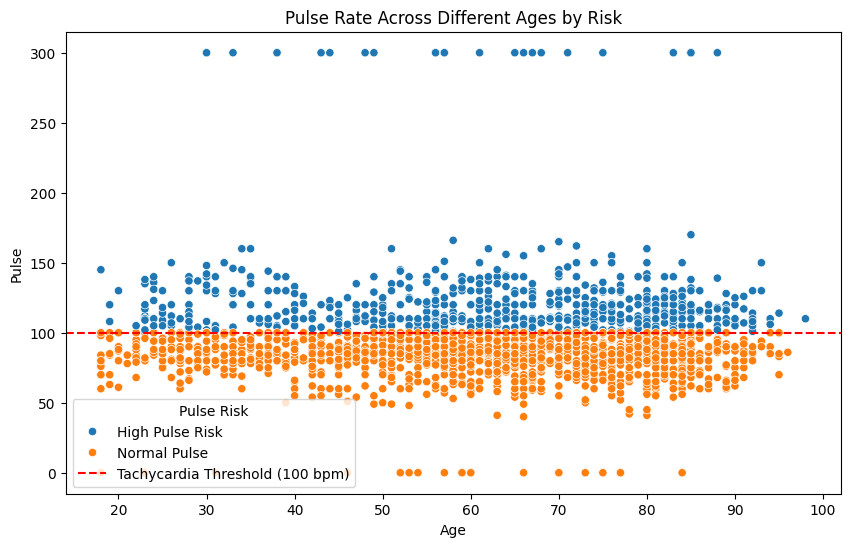

In [16]:
# -------------------------------
# Scatter Plot
# -------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(x="Age", y="pulse", hue="Risk", data=df)
plt.axhline(100, color='red', linestyle='--', label='Tachycardia Threshold (100 bpm)')

plt.title("Pulse Rate Across Different Ages by Risk")
plt.xlabel("Age")
plt.ylabel("Pulse")
plt.legend(title='Pulse Risk')

plt.show()

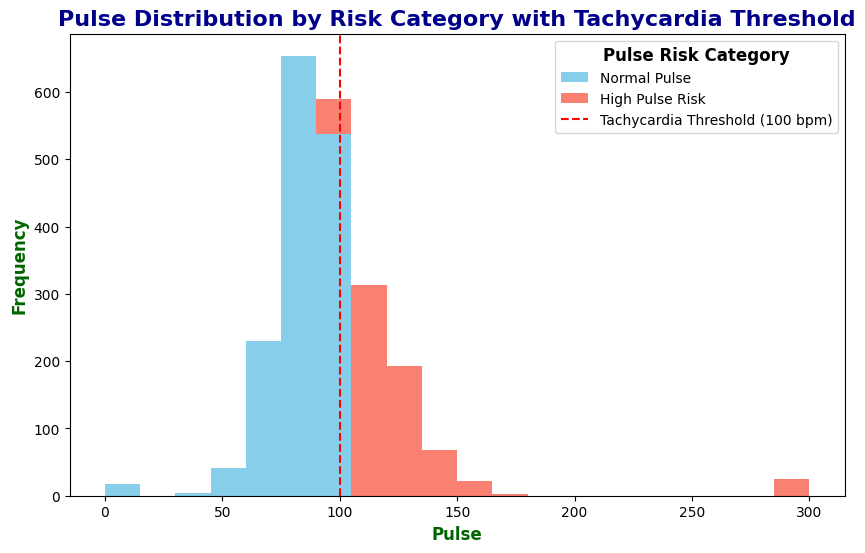

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Histogram
# -------------------------------

plt.figure(figsize=(10,6))

# Filter data by 'Risk' category
pulse_normal = df[df['Risk'] == 'Normal Pulse']['pulse']
pulse_high_risk = df[df['Risk'] == 'High Pulse Risk']['pulse']

# Plot histograms for each risk group with different colors
plt.hist([pulse_normal, pulse_high_risk], bins=20, stacked=True, color=['skyblue', 'salmon'], label=['Normal Pulse', 'High Pulse Risk'])

# Clinical threshold for tachycardia
plt.axvline(100, color='red', linestyle='--', label='Tachycardia Threshold (100 bpm)')

plt.title("Pulse Distribution by Risk Category with Tachycardia Threshold", fontdict={'fontsize': 16, 'fontweight': 'bold', 'color': 'darkblue'})
plt.xlabel("Pulse", fontdict={'fontsize': 12, 'fontweight': 'bold', 'color': 'darkgreen'})
plt.ylabel("Frequency", fontdict={'fontsize': 12, 'fontweight': 'bold', 'color': 'darkgreen'})

# Create the legend and then set the font weight of its title
legend = plt.legend(title='Pulse Risk Category', title_fontsize=12)
legend.get_title().set_fontweight('bold')

plt.show()

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/EmergencyTriageDataset_Reduced_Dirty.csv")

# Convert pulse and Age columns to numeric
df["pulse"] = pd.to_numeric(df["pulse"], errors="coerce")
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Remove missing values
df = df.dropna(subset=["pulse", "Age"])

# Create risk labels
df["Risk"] = df["pulse"].apply(
    lambda x: "High Pulse Risk" if x > 100 else "Normal Pulse"
)

# Display first few rows of the processed DataFrame
print("First few rows of the processed DataFrame:")
display(df[["pulse", "Age", "Risk"]].head())

First few rows of the processed DataFrame:


,pulse,Age,Risk
0,128.0,34,High Pulse Risk
1,80.0,20,Normal Pulse
2,92.0,77,Normal Pulse
3,100.0,23,Normal Pulse
4,85.0,86,Normal Pulse


Some patients in the dataset presented with Pulse values above 100 bpm, which may indicate tachycardia in a clinical setting. By visualizing the pulse distribution alongside a clinical threshold, it becomes easier to identify potentially abnormal readings and understand patterns within the triage data. The scatter plot also helps explore how pulse values vary across different age groups.